In [1]:
from pathlib import Path
import json
import shutil
import pandas as pd
from collections import Counter
from typing import Dict
import sys

import kagglehub
from tqdm import tqdm

REPO_ROOT = Path.cwd().parents[1]
sys.path.append(str(REPO_ROOT))

RAW_ROOT = REPO_ROOT / 'data' / 'raw'
DATASET_NAME = 'fundus'
TARGET_ROOT = RAW_ROOT / DATASET_NAME
SOURCE_ID = 'mariaherrerot/aptos2019'

IMG_EXTS = {'.png', '.jpg', '.jpeg'}

CLASS_NAMES = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']

print('Repo root:', REPO_ROOT)
print('Target root:', TARGET_ROOT)
print('Kaggle source id:', SOURCE_ID)
print('Classes:', CLASS_NAMES)

Repo root: d:\git projects\certified-attribution-medical-imaging
Target root: d:\git projects\certified-attribution-medical-imaging\data\raw\fundus
Kaggle source id: mariaherrerot/aptos2019
Classes: ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']


## Download dataset

Pull the preprocessed APTOS dataset from KaggleHub. It should contain `train_images/`, `val_images/`, `test_images/` and corresponding CSV files.


In [2]:
source_path = Path(kagglehub.dataset_download(SOURCE_ID))
print('KaggleHub path:', source_path)

# Locate CSV files and image directories
csv_files = list(source_path.rglob('*.csv'))
print(f'\nFound {len(csv_files)} CSV files:')
for csv in csv_files:
    print(f'  {csv.name}')

image_dirs = [d for d in source_path.rglob('*') if d.is_dir() and 'image' in d.name.lower()]
print(f'\nFound {len(image_dirs)} image directories:')
for img_dir in image_dirs:
    count = len([f for f in img_dir.rglob('*') if f.suffix.lower() in IMG_EXTS])
    print(f'  {img_dir.name}: {count} images')

100%|██████████| 8.01G/8.01G [14:15<00:00, 10.1MB/s]  

Extracting files...


KaggleHub path: C:\Users\farih\.cache\kagglehub\datasets\mariaherrerot\aptos2019\versions\3

Found 3 CSV files:
  test.csv
  train_1.csv
  valid.csv

Found 6 image directories:
  test_images: 366 images
  train_images: 2930 images
  val_images: 366 images
  test_images: 366 images
  train_images: 2930 images
  val_images: 366 images


## Convert CSV to JSON and reorganize

Read CSV files (train_1.csv, valid.csv, test.csv), convert to `labels.json`, and copy images into `data/raw/fundus/{train,val,test}/images/`.


In [4]:
def find_csv(root: Path, names: list) -> Path:
    for name in names:
        candidates = list(root.rglob(name))
        if candidates:
            return candidates[0]
    return None


def find_image_dir(root: Path, names: list) -> Path:
    for name in names:
        candidates = [d for d in root.rglob(name) if d.is_dir()]
        if candidates:
            return candidates[0]
    return None


# Map split names to CSV and image directory names
split_mapping = {
    'train': {
        'csv': ['train_1.csv', 'train.csv'],
        'img_dir': ['train_images', 'train'],
    },
    'val': {
        'csv': ['valid.csv', 'val.csv'],
        'img_dir': ['val_images', 'valid_images', 'val'],
    },
    'test': {
        'csv': ['test.csv'],
        'img_dir': ['test_images', 'test'],
    }
}


def prepare_fundus_splits(source_root: Path, target_root: Path, split_mapping: Dict):
    if target_root.exists():
        shutil.rmtree(target_root)
    target_root.mkdir(parents=True, exist_ok=True)
    
    stats = {}
    
    for split, config in split_mapping.items():
        print(f'\nProcessing {split} split...')
        
        # Find CSV
        csv_path = find_csv(source_root, config['csv'])
        if not csv_path:
            print(f'  ⚠ CSV not found for {split}, skipping')
            continue
        print(f'  CSV: {csv_path.name}')
        
        # Find image directory
        img_dir = find_image_dir(source_root, config['img_dir'])
        if not img_dir:
            print(f'  ⚠ Image directory not found for {split}, skipping')
            continue
        print(f'  Images: {img_dir.name}')
        
        # Handle nested folders (e.g., train_images/train_images) and index images recursively
        children = list(img_dir.iterdir())
        if len(children) == 1 and children[0].is_dir():
            img_dir = children[0]
            print(f'  Using nested dir: {img_dir.name}')
        
        all_images = {p.stem: p for p in img_dir.rglob('*') if p.is_file() and p.suffix.lower() in IMG_EXTS}
        print(f'  Indexed {len(all_images)} images (recursive)')
        
        # Read CSV
        df = pd.read_csv(csv_path)
        print(f'  Loaded {len(df)} entries from CSV')
        
        # Create target directories
        target_split_dir = target_root / split
        target_images_dir = target_split_dir / 'images'
        target_images_dir.mkdir(parents=True, exist_ok=True)
        
        # Convert to labels.json and copy images
        labels = {}
        class_counter = Counter()
        missing = 0
        
        for _, row in tqdm(df.iterrows(), total=len(df), desc=f'  Copying {split}'):
            id_code = str(row['id_code'])
            diagnosis = int(row['diagnosis'])
            
            # Resolve source image by id (handles nested folders)
            src_img = all_images.get(id_code)
            if src_img is None:
                base = Path(id_code)
                if base.suffix:
                    src_img = all_images.get(base.stem)
            
            if src_img is None:
                missing += 1
                continue
            
            # Copy image with consistent naming
            dest_name = Path(id_code)
            dest_name = dest_name.name if dest_name.suffix else f'{id_code}{src_img.suffix.lower()}'
            dest_path = target_images_dir / dest_name
            shutil.copy2(src_img, dest_path)
            
            labels[dest_name] = diagnosis
            class_counter[diagnosis] += 1
        
        # Save labels.json
        labels_path = target_split_dir / 'labels.json'
        with open(labels_path, 'w') as f:
            json.dump(labels, f, indent=2)
        
        stats[split] = {
            'total': len(labels),
            'missing': missing,
            'class_distribution': dict(class_counter)
        }
        
        print(f'  ✓ Saved {len(labels)} samples')
        if missing > 0:
            print(f'  ⚠ {missing} images not found')
    
    # Print summary
    print('\n' + '='*80)
    print('SUMMARY')
    print('='*80)
    for split, info in stats.items():
        print(f'\n{split.upper()}:')
        print(f'  Total: {info["total"]}')
        if info['missing'] > 0:
            print(f'  Missing: {info["missing"]}')
        print(f'  Class distribution:')
        for cls, count in sorted(info['class_distribution'].items()):
            cls_name = CLASS_NAMES[cls] if cls < len(CLASS_NAMES) else str(cls)
            print(f'    {cls} ({cls_name}): {count}')


prepare_fundus_splits(source_path, TARGET_ROOT, split_mapping)



Processing train split...
  CSV: train_1.csv
  Images: train_images
  Using nested dir: train_images
  Indexed 2930 images (recursive)
  Loaded 2930 entries from CSV


  Copying train: 100%|██████████| 2930/2930 [00:10<00:00, 283.42it/s]


  ✓ Saved 2930 samples

Processing val split...
  CSV: valid.csv
  Images: val_images
  Using nested dir: val_images
  Indexed 366 images (recursive)
  Loaded 366 entries from CSV


  Copying val: 100%|██████████| 366/366 [00:01<00:00, 253.76it/s]


  ✓ Saved 366 samples

Processing test split...
  CSV: test.csv
  Images: test_images
  Using nested dir: test_images
  Indexed 366 images (recursive)
  Loaded 366 entries from CSV


  Copying test: 100%|██████████| 366/366 [00:01<00:00, 255.92it/s]

  ✓ Saved 366 samples

SUMMARY

TRAIN:
  Total: 2930
  Class distribution:
    0 (No DR): 1434
    1 (Mild): 300
    2 (Moderate): 808
    3 (Severe): 154
    4 (Proliferative DR): 234

VAL:
  Total: 366
  Class distribution:
    0 (No DR): 172
    1 (Mild): 40
    2 (Moderate): 104
    3 (Severe): 22
    4 (Proliferative DR): 28

TEST:
  Total: 366
  Class distribution:
    0 (No DR): 199
    1 (Mild): 30
    2 (Moderate): 87
    3 (Severe): 17
    4 (Proliferative DR): 33


## Verify with `FundusDataset`

Load the prepared dataset using our custom loader and check sample counts.


In [5]:
from torchvision import transforms
from src.datasets.fundus import FundusDataset

tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = FundusDataset(root_dir=str(TARGET_ROOT), split='train', transform=tf)
val_ds = FundusDataset(root_dir=str(TARGET_ROOT), split='val', transform=tf)
test_ds = FundusDataset(root_dir=str(TARGET_ROOT), split='test', transform=tf)

print('Dataset sizes:', len(train_ds), len(val_ds), len(test_ds))
print('Total:', len(train_ds) + len(val_ds) + len(test_ds))

sample = train_ds[0]
print('\nSample keys:', sample.keys())
print('Image shape:', sample['image'].shape)
print('Label:', sample['label'], f'({train_ds.classes[sample["label"]]})')

Dataset sizes: 2930 366 366
Total: 3662

Sample keys: dict_keys(['image', 'label', 'meta'])
Image shape: torch.Size([3, 224, 224])
Label: 2 (Moderate)


## Visualize sample images

Display a grid of random fundus photographs with their DR severity labels.


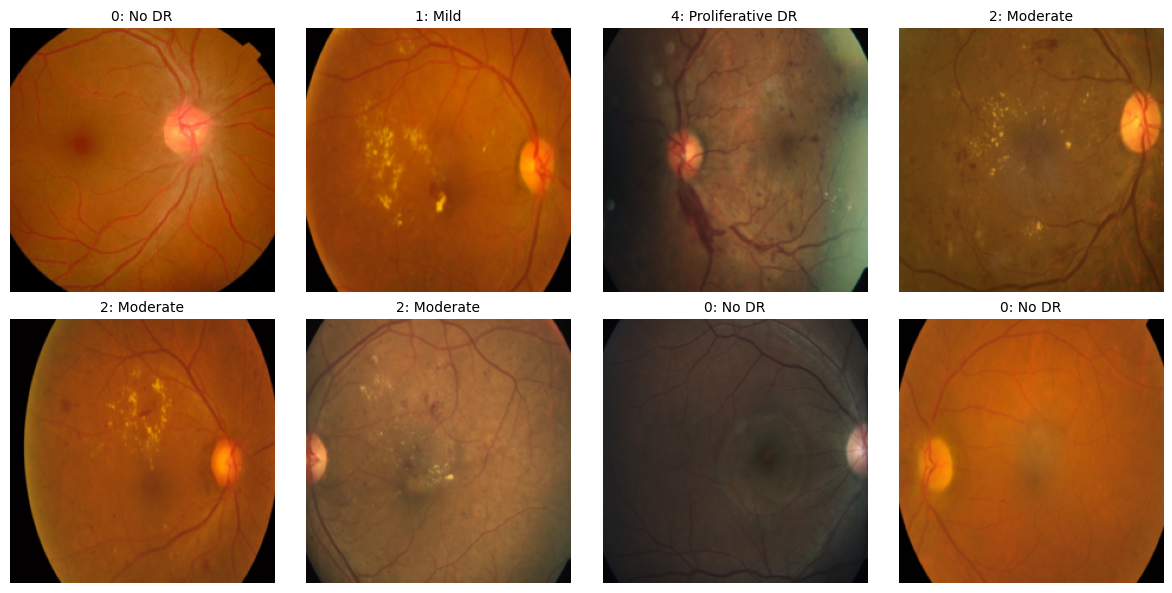

In [6]:
import torch
import matplotlib.pyplot as plt

IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD = [0.229, 0.224, 0.225]

def denorm(img):
    img = img.clone()
    for c in range(3):
        img[c] = img[c] * IMG_STD[c] + IMG_MEAN[c]
    return img.clamp(0, 1)

def show_samples(ds, n=8):
    n = min(n, len(ds))
    cols = 4
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(cols * 3, rows * 3))
    indices = torch.randperm(len(ds))[:n]
    for i, idx in enumerate(indices):
        sample = ds[idx]
        img = denorm(sample['image'])
        label = sample['label']
        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img.permute(1, 2, 0).cpu().numpy())
        title = f"{label}: {ds.classes[label]}"
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(train_ds, n=8)